In [37]:
import lightkurve as lk 
import matplotlib.pyplot as plt 
import numpy as np 

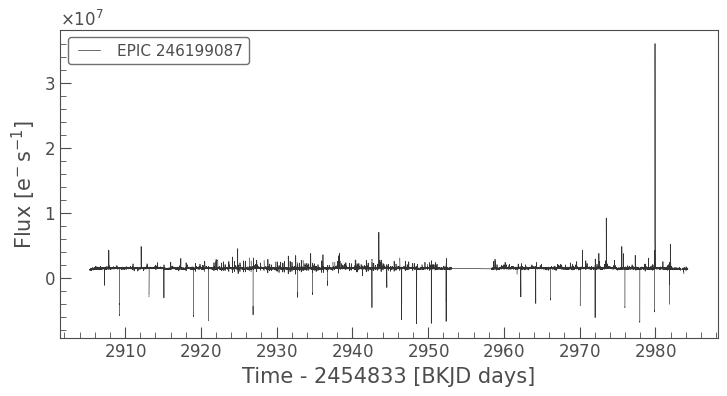

In [38]:
# Search for stellar light data from the Kepler mission
search_result = lk.search_lightcurve('TRAPPIST-1', author='K2')

# This downloads the first "quarter" of data available
lc = search_result[0].download()

# Plot it to see the raw brightness of the star
lc.plot()
plt.show()

In [39]:
# Flatten the light curve
flat_lc = lc.flatten(window_length=401)

# Plot the flattened version
flat_lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

In [40]:
# Run the Box Least Squares (BLS) algorithm
periodogram = flat_lc.to_periodogram(method='bls', period=np.arange(5, 7, 0.001))

# Find the best orbital period
best_period = periodogram.period_at_max_power
print(f"Potential Planet Period: {best_period}")

# Fold the data (overlay all transits to see the shape)
folded_lc = flat_lc.fold(period=best_period)
folded_lc.plot()

Potential Planet Period: 5.8880000000002966 d


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

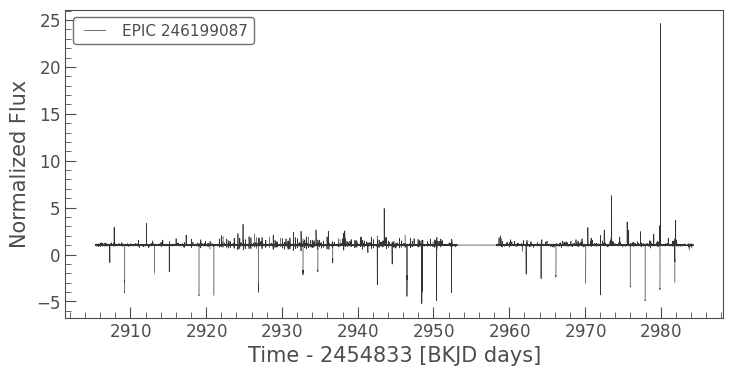

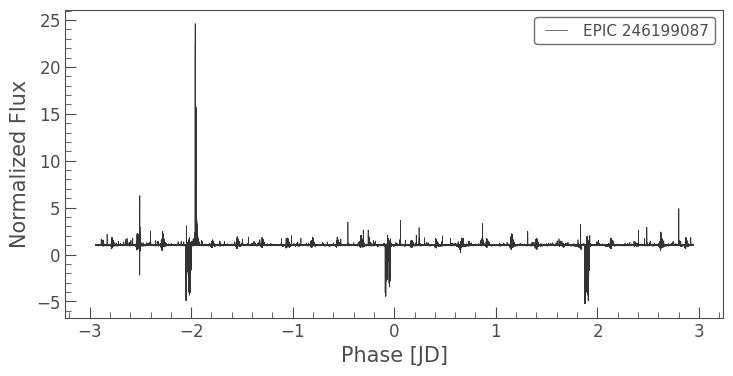

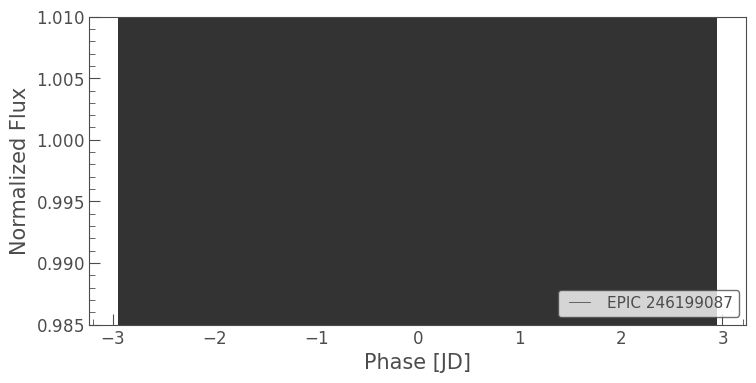

The detected orbital period is: 5.8880000000002966 d days


In [41]:
best_period = periodogram.period_at_max_power
folded_lc = flat_lc.fold(period=best_period)
folded_lc.plot()
plt.ylim(0.985, 1.01) #Zoom on the transit for better visibility
plt.show()
# This line finds the number
best_period = periodogram.period_at_max_power

# This line "runs" the output so you can read it
print(f"The detected orbital period is: {best_period} days")

In [42]:
import pandas as pd
Strip_Period=best_period.value
data={"Period days":[Strip_Period]}
df=pd.DataFrame(data)
print(df)
df.to_csv("Detected_Planet_Period.csv", index=False)


   Period days
0        5.888
